In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\stm10\OneDrive\Desktop\ExamScore.csv") 

In [3]:
data.shape

(5, 5)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Name                 5 non-null      object
 1   Score                5 non-null      int64 
 2   Pass/Fail            5 non-null      int64 
 3   Study Hours          5 non-null      int64 
 4   Previous Exam Score  5 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 332.0+ bytes


In [5]:
data.head(5)

,Name,Score,Pass/Fail,Study Hours,Previous Exam Score
0,Ali,80,1,10,75
1,Sara,40,0,2,35
2,Mona,90,1,12,85
3,Ahmed,75,0,4,70
4,Hoda,70,1,8,65


In [6]:
data.duplicated()

0    False
1    False
2    False
3    False
4    False
dtype: bool

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.nunique()

Name                   5
Score                  5
Pass/Fail              2
Study Hours            5
Previous Exam Score    5
dtype: int64

In [9]:
data.isnull()

,Name,Score,Pass/Fail,Study Hours,Previous Exam Score
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False


In [10]:
data.isnull().sum()

Name                   0
Score                  0
Pass/Fail              0
Study Hours            0
Previous Exam Score    0
dtype: int64

In [11]:
cat_col=[col for col in data.columns if data[col].dtype =='object']
num_col=[col for col in data.columns if data[col].dtype !='object']

In [12]:
print("categorical columns=" , cat_col)
print("numerical columns=" , num_col)

categorical columns= ['Name']
numerical columns= ['Score', 'Pass/Fail', 'Study Hours', 'Previous Exam Score']


In [13]:
data.isnull().sum()

Name                   0
Score                  0
Pass/Fail              0
Study Hours            0
Previous Exam Score    0
dtype: int64

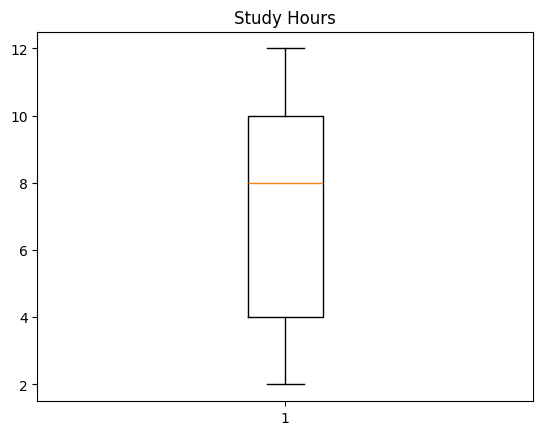

In [14]:
plt.boxplot(data['Study Hours'])
plt.title("Study Hours")
plt.show()

In [15]:
from numpy._core.defchararray import upper
data['Study Hours']=pd.to_numeric(data['Study Hours'],errors='coerce')
data['Previous Exam Score	']=pd.to_numeric(data['Previous Exam Score'],errors='coerce')
def outlier(col):
  Q1=data[col].quantile(0.25)
  Q3=data[col].quantile(0.75)
  IQR=Q3-Q1
  lower =Q1-1.5*IQR
  upper=Q3+1.5*IQR
  data[col]=data[col].clip(Lower,Upper)

  outlier('Study Hours')
  outlier('Previous Exam Score')

C:\Users\stm10\AppData\Local\Temp\ipykernel_16248\1517770541.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pass_or_fail.index,y=pass_or_fail.values,palette=['red','blue'])


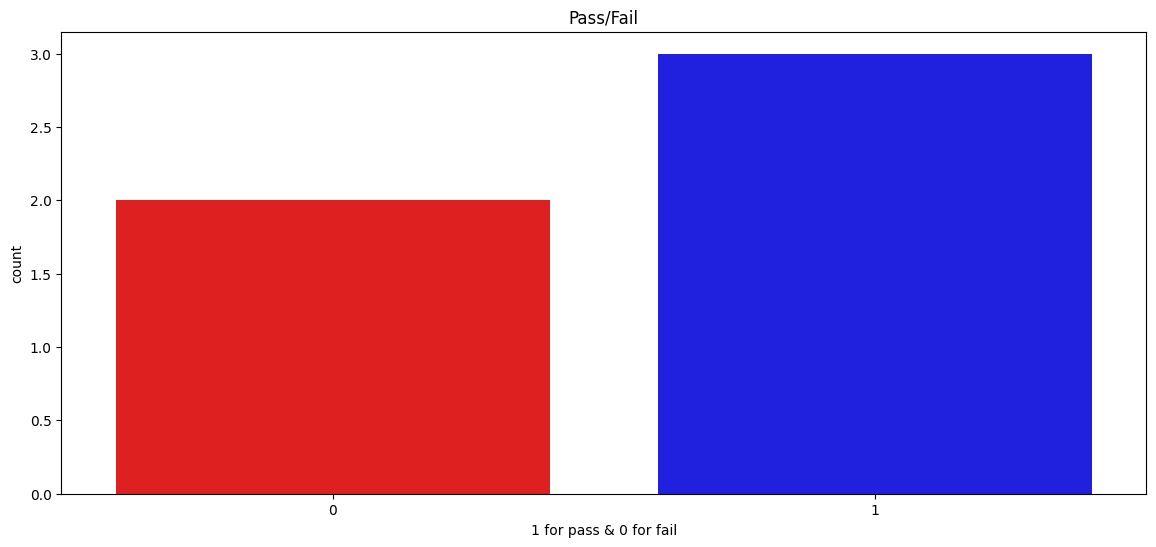

In [16]:
from numpy import poly
pass_or_fail = data['Pass/Fail'].value_counts()
plt.figure(figsize=(14,6))
sns.barplot(x=pass_or_fail.index,y=pass_or_fail.values,palette=['red','blue'])
plt.title('Pass/Fail')
plt.xlabel('1 for pass & 0 for fail')
plt.ylabel('count')
plt.show()

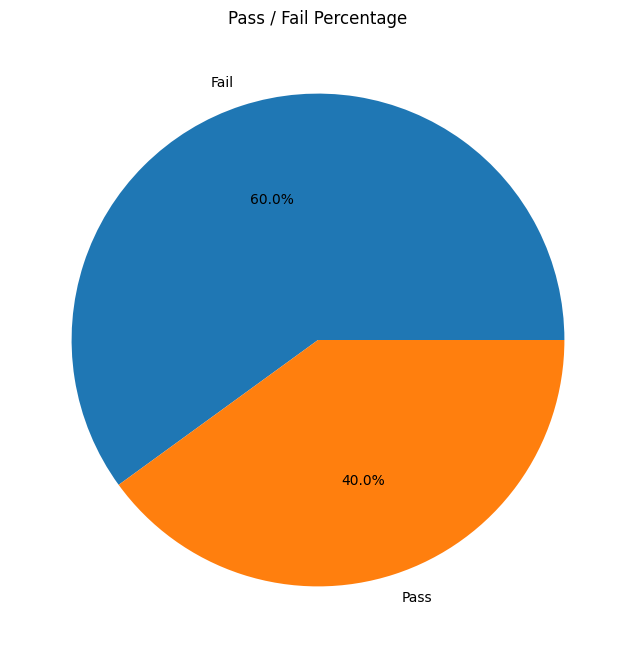

In [17]:
pass_counts = data['Pass/Fail'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    pass_counts.values,
    labels=['Fail','Pass'],
    autopct='%1.1f%%'
)
plt.title('Pass / Fail Percentage')
plt.show()

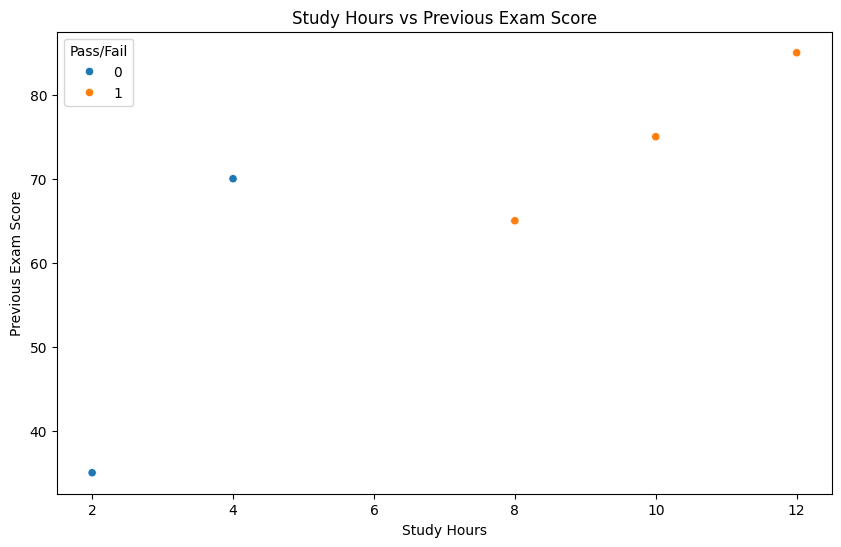

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Study Hours',
    y='Previous Exam Score',
    hue='Pass/Fail',
    data=data
)
plt.title('Study Hours vs Previous Exam Score')
plt.show()

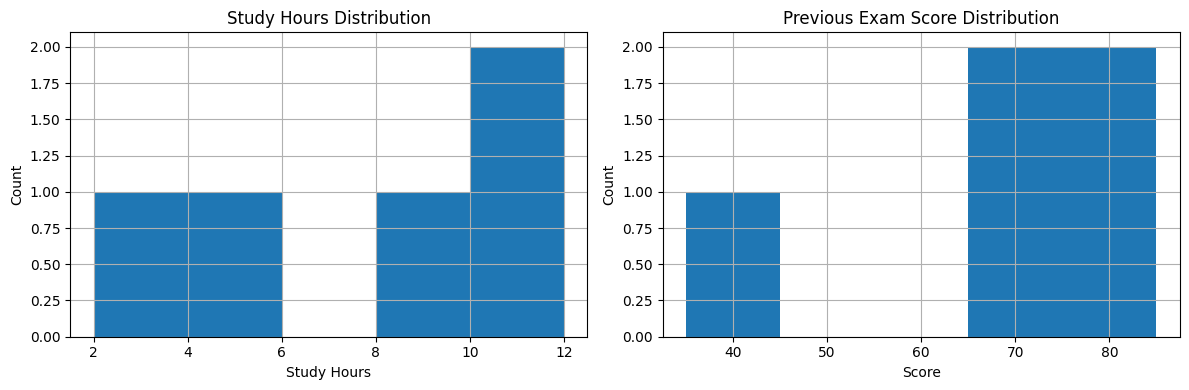

In [19]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
data['Study Hours'].hist(bins=5)
plt.title('Study Hours Distribution')
plt.xlabel('Study Hours')
plt.ylabel('Count')

plt.subplot(1,2,2)
data['Previous Exam Score'].hist(bins=5)
plt.title('Previous Exam Score Distribution')
plt.xlabel('Score')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

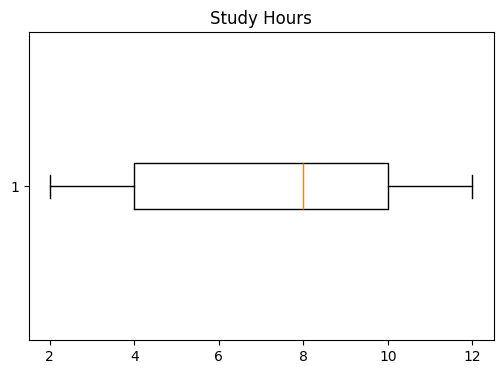

In [20]:
plt.figure(figsize=(6,4))
plt.boxplot(data['Study Hours'], vert=False)
plt.title('Study Hours')
plt.show()

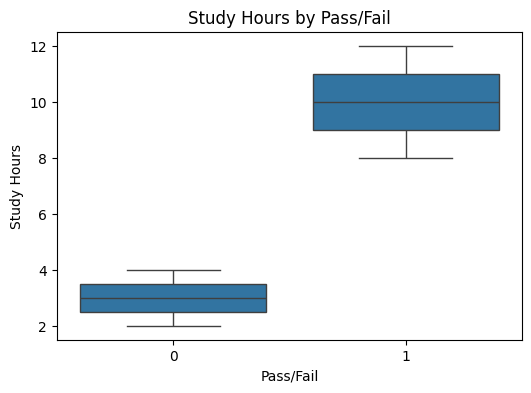

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Pass/Fail', y='Study Hours', data=data)
plt.title('Study Hours by Pass/Fail')
plt.show()

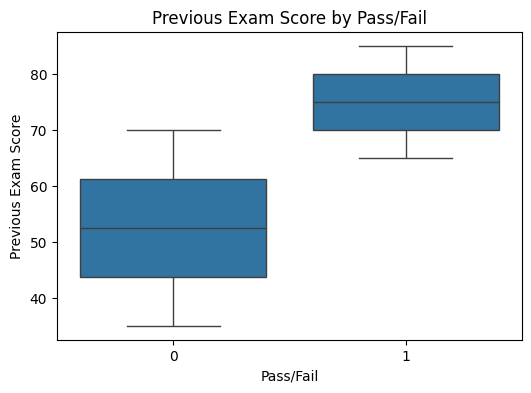

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Pass/Fail', y='Previous Exam Score', data=data)
plt.title('Previous Exam Score by Pass/Fail')
plt.show()

c:\Users\stm10\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\stm10\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


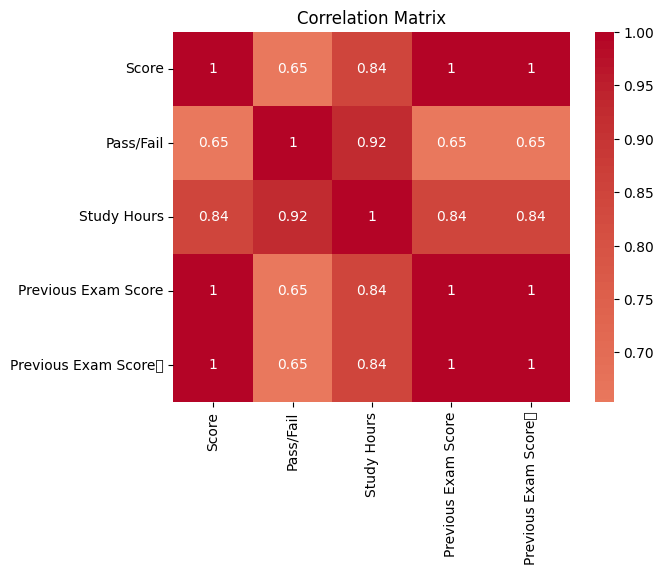

In [23]:


corr = data.select_dtypes(include=['number']).corr()

# رسم الـ Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [24]:
# Features & Target
X = data[['Study Hours', 'Previous Exam Score']]
y = data['Pass/Fail']

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



c:\Users\stm10\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\stm10\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\stm10\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



c:\Users\stm10\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


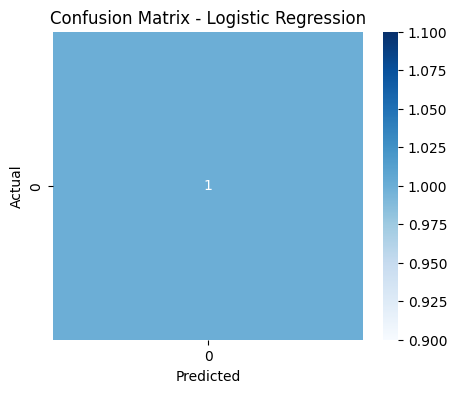

In [29]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()